# Analysis of Radio Static as a Candidate CMB-Related Signal

#                                      Scientific Python Final Project

# Data analysis, signal processing, image reconstruction and statistical testing

## 1. Introduction and Research Question

The peculiar determination to comprehend the universe, driven by an unquenched and unhindered intrinsic motivation, has accompanied humankind since its earliest origins; yet the origin of the cosmos itself lies in a far more remote past—a past not perished, but preserved in the faintest traces of radiation that still surrounds us today. 
Withered may be, point a microwave telescope at almost any direction in the sky and, after accounting for the foreground emission produced by astrophysical sources, one encounteres isotropic and nearly the uniform radiation field.
The radiation that we observe today began its journey when the Universe was still solely nascent, at a time when matter and radiation had only just ceased to be tightly coupled. Since then, the Universe has expanded, the radiation has cooled and its wavelength has been stretched into the microwave part of the electromagnetic spectrum. What reaches us today is therefore not merely radiation from a distant object, but a surviving trace of an earlier state of the Universe.
What initially looked like an unwanted background was eventually established as something much more profound: a remnant of the hot early Universe. 

This raises a simple question which is almost deliberately naive:

How simple can an instrument be and still reveal something that belongs to the history of the Universe?
The question that motivated the present project was not whether a small pocket radio could replace a dedicated astronomical instrument. It clearly cannot. Rather, it was whether an ordinary, overlooked receiver — a device small enough to be held in the palm of a hand — could record a signal containing structure worthy of being investigated as a possible vestige or candidate component of a much larger cosmic background.
The CMB itself is an exceptionally weak and virtually uniform signal. Although minute these fluctuations are far from random noise; they are the physical signatures of primordial conditions of matter in the early universe. A real radio recording, however, is never composed of the desired component alone. It may contain instrumental interference, environmental contributions, atmospheric effects and other forms of radio-frequency noise. The scientific problem therefore becomes not simply to produce a structured image from the signal, but to determine whether the observed structure differs from what could reasonably be produced by suitable randomized versions of the same data.

The complete analysis follows a sequence of transformations:

**recorded signal → preprocessing → two-dimensional computational representation → Fourier filtering → reconstructed field → structure detection → statistical comparison with null models.**

Throughout the analysis, particular attention is given to the distinction between a computational reconstruction and a physically calibrated astronomical map.

# 2. Strategy of Project Development

To investigate this question, the analysis follows a sequence in which each processing step serves a specific purpose. The recorded signal is first inspected and cleaned of a narrow instrumental contribution. A sufficiently long portion of the resulting one-dimensional signal is then rearranged into a two-dimensional computational field. This representation allows image-processing and spatial-frequency methods to be applied to the data.

The two-dimensional field is analysed in the Fourier domain, where its spatial-frequency components can be separated. A low-pass filter is then used to retain the large-scale component of the field. After reconstruction, the resulting pattern is smoothed and segmented so that its connected structures can be identified and quantified.

The observed structures are subsequently examined statistically. A bootstrap procedure is used to investigate the variability of the measured mean structure area, while two independent null-model approaches are used to test the structure count. The first randomly rearranges the recorded samples, destroying their original ordering while preserving their individual amplitudes. The second preserves the Fourier amplitude spectrum but randomises the phases, thereby retaining the overall spectral content while removing the original phase organisation.

The analysis can therefore be summarised as:

recording → preprocessing → 2D representation → contrast enhancement → Fourier analysis → low-pass reconstruction → structure detection → statistical testing

# 3. Data Acquisition and Initial Inspection

The analysis begins with a short recording of radio static obtained while a pocket radio was tuned between stations. The recorded signal provides the experimental input for the entire analysis and is therefore examined before any substantial processing is applied.

The recording contains two audio channels. Rather than immediately combining them, the two channels are first compared numerically through their correlation coefficient. This provides a simple measure of how similarly the two channels record the same underlying signal. A strong correlation indicates that the channels contain substantially shared information, while a weak correlation would suggest that treating them independently may be more appropriate.

After this initial comparison, the channels are averaged to obtain a single mono signal. The resulting signal is then inspected in the time domain before proceeding to the subsequent preprocessing steps.

In [5]:
import sys
from pathlib import Path

sys.path.append(str(Path.cwd() / "src"))

In [6]:
import acquisition

project = acquisition.project

# 3.1 Stereo Channel Correlation

The two recorded channels show a Pearson correlation coefficient of 0.8201. This indicates a substantial degree of similarity between the signals recorded by the two channels, suggesting that a large part of their variation is shared rather than being independent channel-specific noise.

Based on this result, the two channels are averaged sample by sample to produce a single mono signal. This reduces the representation to one signal while retaining the common component present in both channels.

The resulting signal contains 1 048 576 samples, which is the exact number required to construct the 1024x1024 computational field used later in the analysis.

# 4. Signal Preprocessing

A recorded radio signal contains both the variations of interest and contributions introduced by the measurement environment and the receiving system. Before investigating its larger-scale structure, it is therefore necessary to reduce identifiable instrumental interference while preserving as much of the remaining signal as possible.

The two stereo channels were first averaged to form the mono signal described above. The resulting signal was then converted to floating-point representation and passed through a narrow notch filter centred at 82.8 Hz, with a quality factor of (Q=30).

A notch filter is appropriate when an unwanted contribution is concentrated within a narrow frequency interval. Rather than suppressing a broad region of the spectrum, it selectively attenuates the component around the specified frequency while leaving neighbouring frequencies comparatively unaffected. In this analysis, the filter is therefore used to remove the identified 82.8 Hz instrumental contribution before the signal is transformed into its two-dimensional representation.

The filtering was performed using a forward-backward procedure, so that the resulting signal is not shifted in time by the filtering operation. The filtered signal is then retained for the subsequent stages of the analysis.

# 5. From a 1D Signal to a 2D Computational Field

The filtered recording is originally a one-dimensional sequence: the measured amplitude varies as a function of time. To investigate its structure using image-processing and spatial-frequency methods, the signal is rearranged into a two-dimensional numerical field.

Exactly 1,048,576 samples are retained from the filtered recording. Allowing the samples to be rearranged into a 1024x1024 array. Consecutive portions of the one-dimensional signal are therefore placed along successive rows of the resulting field.

The resulting 1024x1024 array is not a physical map of the sky: its horizontal and vertical coordinates do not correspond to celestial longitude, latitude, or any calibrated angular position. It is instead a computational representation of the original signal that makes it possible to apply two-dimensional image-processing and Fourier methods.

The resulting field is then normalised and its local contrast is enhanced before Fourier-domain analysis.

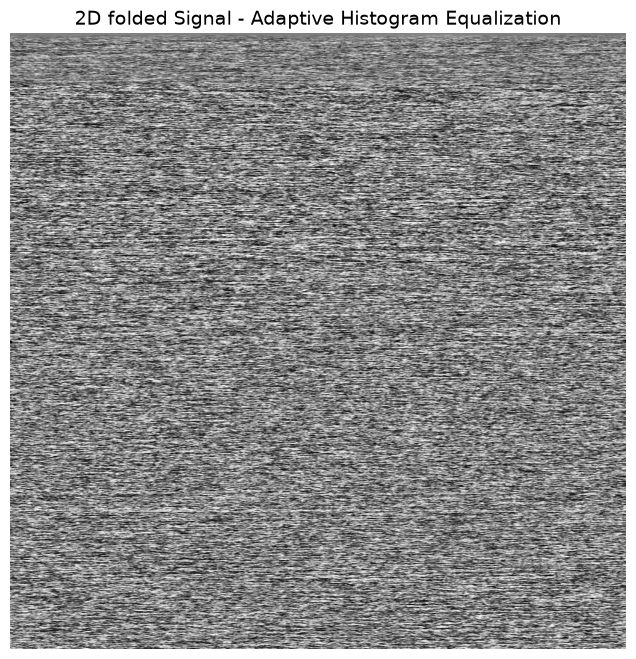

In [7]:
from preprocessing import preprocess

preprocess(project)

# 6. Contrast Enhancement

The numerical values of the folded field are first normalised to the interval [0, 1]. This changes the scale of the representation without changing the relative ordering of the signal amplitudes. Normalisation provides a common intensity range for the subsequent image-processing operations.

The normalised field is then processed using Contrast Limited Adaptive Histogram Equalization (CLAHE). Unlike a conventional global contrast adjustment, CLAHE operates on local regions of the image. It enhances intensity differences within these regions while limiting excessive amplification of local variations.

This step is useful because structures that are weak relative to the overall intensity distribution may not be readily distinguishable in the original numerical field. Enhancing local contrast makes variations within the computational field more suitable for subsequent spatial-frequency analysis.

The resulting image should therefore be understood as a processed representation of the signal, rather than as a direct physical image. The contrast enhancement changes how the numerical field is represented visually and subsequently analysed.

# 7. Fourier-Domain Analysis

The contrast-enhanced two-dimensional field contains variations occurring on different spatial scales. Some changes extend gradually across large portions of the field, while others occur over much smaller distances. To separate these components, the processed field is transformed from the spatial domain into the Fourier domain.

The two-dimensional Fourier transform decomposes the field into spatial-frequency components. Low spatial frequencies describe slowly varying, large-scale structures, whereas high spatial frequencies describe more rapid local variations, including fine structures and sharp changes.

In this analysis, the Fourier transform is calculated using fft2. The zero-frequency component is then moved to the centre of the spectrum using fftshift, making the distribution of spatial frequencies easier to visualise and allowing a radial frequency mask to be defined around the centre.

Because the Fourier spectrum contains a large range of intensities, its visualisation uses logarithmic scaling through log1p. It only makes weak and strong spectral components visible together.

The analysis then applies a circular low-pass mask defined by

            x^2 + y^2 = 12^2

where x and y are coordinates on the centred discrete Fourier grid. The mask therefore retains the lowest spatial-frequency components near the centre of the spectrum and removes higher-frequency components.

The circular shape treats the two directions of the computational field equally, imposing an isotropic frequency selection. The value 12 is a computational Fourier-grid cutoff, not a calibrated physical length or angular scale, because the original recording has not been associated with astronomical spatial coordinates.

This filtering provides the basis for the next stage: reconstructing a two-dimensional field containing predominantly the large-scale variations retained by the low-pass filter.

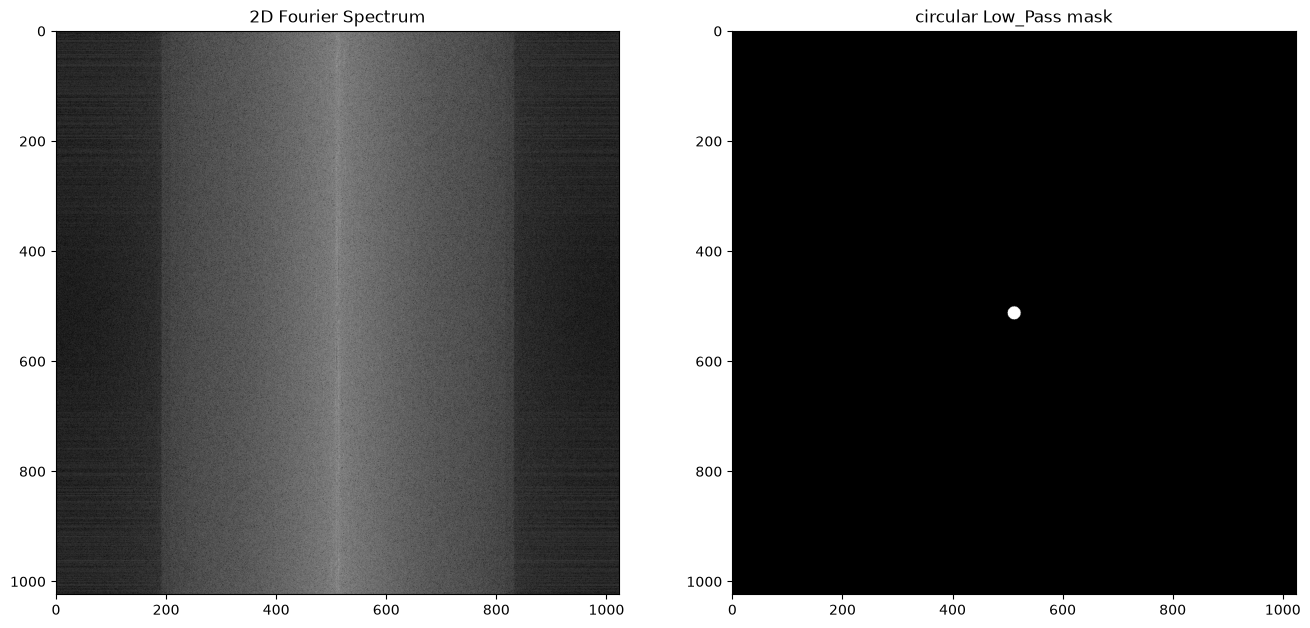

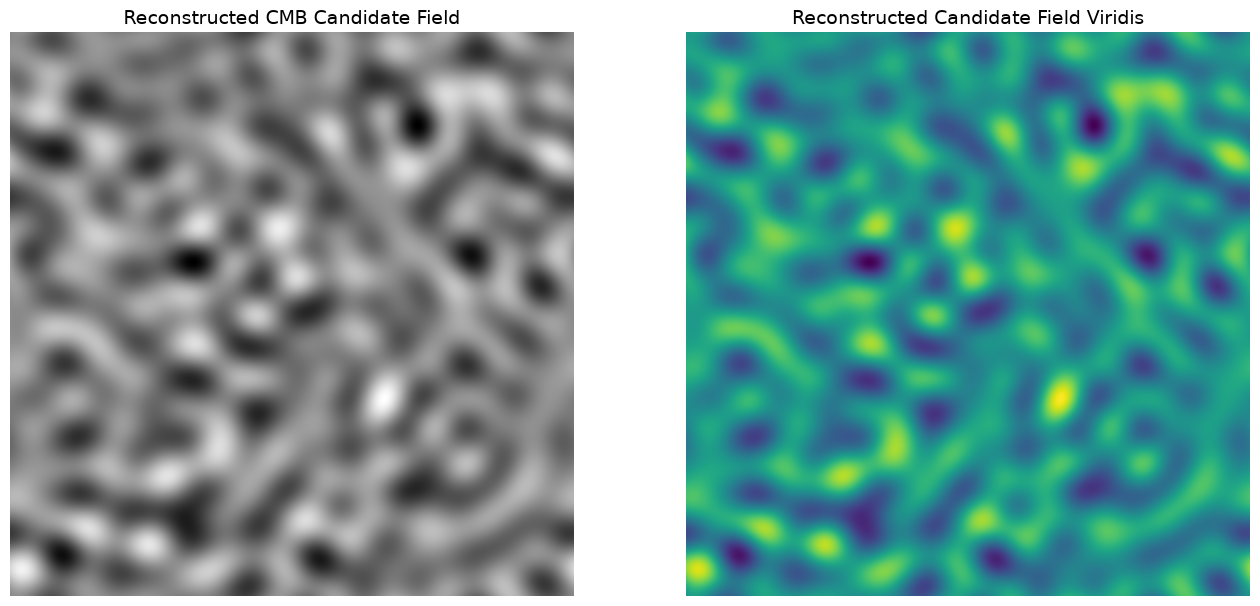

In [16]:
from reconstruction import reconstruct

reconstruct(project)

# 8. Reconstruction

After selecting the low-spatial-frequency components in the Fourier domain, the filtered spectrum is transformed back into the two-dimensional computational domain using the inverse Fourier transform.

The resulting field represents the variations that remain after the higher spatial frequencies have been removed. Because the low-pass mask retains only a small central region of the Fourier spectrum, the reconstructed field is dominated by relatively broad, slowly varying patterns rather than fine-scale fluctuations.

The use of two visualisations provides complementary views of the same numerical field. The grayscale image shows the spatial organisation of the reconstructed intensity directly, while the colour representation makes differences in intensity easier to distinguish visually.

# 9. Morphological Analysis

To make the analysis quantitative, the reconstructed field was converted into a binary representation in which regions of relatively high intensity could be identified and measured.

Before thresholding, the reconstructed field was smoothed with a Gaussian filter with standard deviation: sigma=5

The purpose of this step was to reduce small-scale fluctuations and make the identification of extended structures less sensitive to individual pixel variations.

The intensity threshold was then determined automatically using Otsu's method. Rather than choosing a threshold by visual inspection, Otsu's method selects a value that separates the intensity distribution into two classes by maximizing the separation between them. 

For the original reconstructed field, this procedure identified 8 connected structures.

The areas of these structures were measured in pixels. Their mean area was approximately 70 235 pixels.

The structure count and area measurements obtained here provide the quantities that will subsequently be compared with randomized versions of the signal. In this way, the morphological analysis becomes part of a statistical test rather than simply a visual description of the reconstructed image.

Number of detected structures: 8


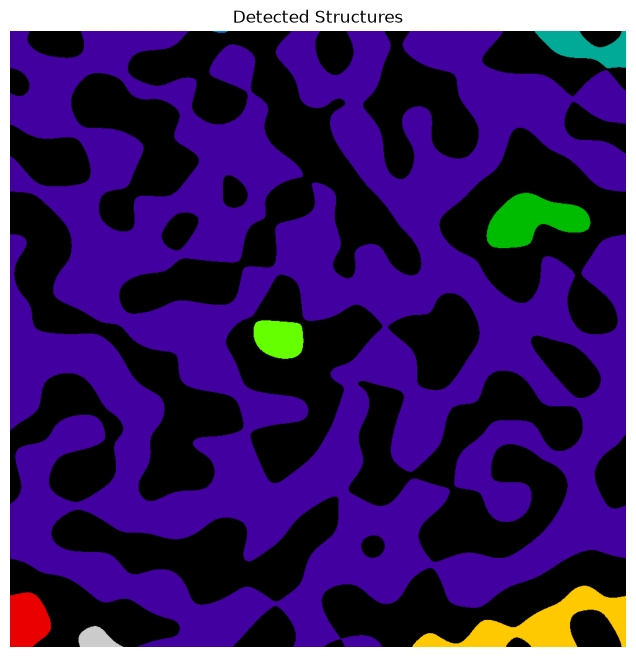

In [17]:
from segmentation import segment

segment(project)

# 10. Uncertainty: Bootstrap

The eight detected structures provide a measured sample from which the mean structure area can be calculated. However, because only a small number of structures were identified, the mean alone does not indicate how stable this estimate is. An uncertainty analysis was therefore performed using bootstrap resampling.

In the bootstrap procedure, the eight measured structure areas were repeatedly resampled with replacement. Each resampled dataset contained the same number of observations as the original dataset, namely eight areas, but an individual structure could appear more than once in a given sample.

For each of 1000 bootstrap samples, the mean structure area was calculated. This produced a distribution of possible mean values based on repeated resampling of the observed structures.

The resulting bootstrap distribution was centred around the observed mean area of approximately 70 235 pixels.

Its standard deviation was 61 440.56 pixels.

The value of 70 235 pixels should not be regarded as a highly precise characteristic of the reconstructed field. Rather, it is an estimate whose variability is substantial under resampling of the available observations.

This uncertainty will be kept in consideration when interpreting the subsequent statistical comparisons with randomized signals.

Observed mean area: 70235 pixels
Bootstrap Standard Deviation of mean area: 62728.97 pixels


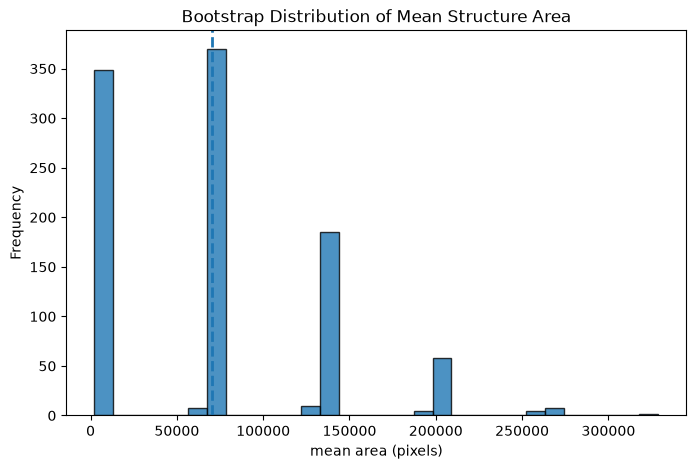

Randomized mean structure count: 17.08
Randomized Standard Deviation: 5.09
Empirical p-value: 0.0594


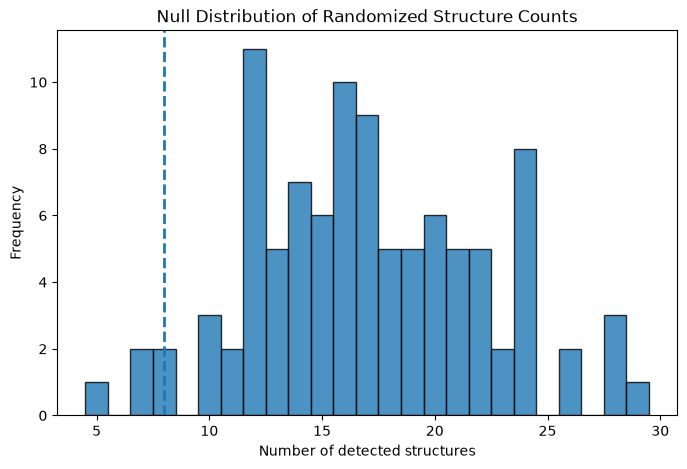

Phase-randomized mean structure count: 14.83
Phase-randomized Standard Deviation: 4.58
Phase-randomized empirical p-value: 0.0891


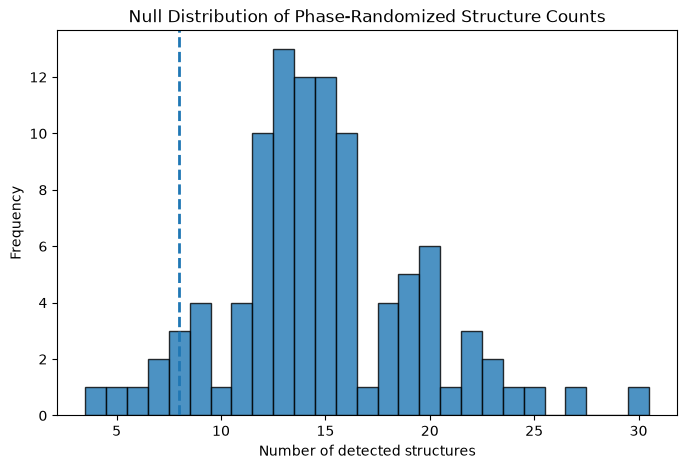

In [23]:
from statistics_analysis import analyze_statistics

analyze_statistics(project)

# 11. Null Model I: Shuffling

To test whether the detected structures depend on the particular temporal ordering of the recorded signal, a shuffle-based null model was constructed. For each trial, the samples of the filtered one-dimensional signal were randomly permuted. This preserves the distribution of signal amplitudes while destroying their original temporal ordering and correlations.

Each shuffled signal was then passed through the same analysis pipeline used for the original recording: reshaping into a 2D field, contrast enhancement, Fourier-domain filtering, inverse reconstruction, Gaussian smoothing, Otsu thresholding, and connected-component analysis. Keeping the processing identical allows the resulting structure counts to be compared directly with those obtained from the original signal.

For the original signal, 8 structures were detected. Across 100 shuffled realisations, the mean number of detected structures was 17.08, with a standard deviation of 5.09. The empirical p-value was 0.0594, calculated as the fraction of shuffled realisations producing a structure count less than or equal to the observed value, with a small-sample correction.

The observed structure count is therefore lower than the centre of the shuffled distribution. However, the empirical p-value remains slightly above the conventional 0.05 threshold. The shuffle-based null model therefore does not provide sufficient statistical evidence to distinguish the observed structure count from the shuffled signals.

# 12. Null Model II: Phase Randomisation

A second null model was constructed using phase randomisation. Unlike simple shuffling, which destroys the temporal ordering of the samples, phase randomisation preserves the amplitude spectrum of the original signal while randomising the phases of its Fourier components. The frequency content of the signal is therefore retained, while its original phase relationships are removed.

Each phase-randomised signal was passed through the same analysis pipeline as the original recording. The resulting structure counts were then compared with the 8 structures detected in the original signal.

Across 100 phase-randomised realisations, the mean number of detected structures was 14.83, with a standard deviation of 4.58. The empirical p-value was 0.0891, calculated as the fraction of phase-randomised realisations producing a structure count less than or equal to the observed value, with a small-sample correction.

As in the shuffle-based test, the observed signal produced fewer structures than the average null realisation. However, the empirical p-value is above the conventional 0.05 threshold. This null model therefore does not provide sufficient statistical evidence to distinguish the observed structure count from the phase-randomised signals.

# 13. Comparison and Statistical Interpretation

The three statistical analyses provide complementary information about the reconstructed candidate field. The bootstrap analysis indicates substantial variability in the estimated mean structure area, with an observed mean of 70,235 pixels and a bootstrap standard deviation of 62,728.97 pixels. This large spread reflects the limited number of detected structures in the original reconstruction and indicates considerable uncertainty in the area-based measurement.

The two null-model tests examine the observed structure count from a different perspective. The original signal produced 8 detected structures, whereas the shuffled signals produced an average of 17.08 structures and the phase-randomised signals produced an average of 14.83 structures. In both cases, the observed count is lower than the mean of the corresponding null distribution.

However, the empirical p-values were 0.0594 for shuffling and 0.0891 for phase randomisation. Both values are above the conventional 0.05 threshold. Therefore, neither null model provides sufficient statistical evidence to reject its respective null hypothesis at the 5% significance level.

Taken together, the results show a difference between the observed reconstruction and the two null models, but the available statistical evidence is not strong enough to establish that this difference is unlikely to arise from the null processes considered. The analysis should therefore be interpreted as a computational investigation of a candidate pattern rather than as evidence of a detected cosmic microwave background signal.

# 14. Limitations

Several limitations must be considered when interpreting the results of this analysis.

First, the original recording is a one-dimensional radio signal, while the two-dimensional field used in the analysis is created by mathematically rearranging the samples into a 1024 × 1024 array. This transformation does not introduce additional information and does not produce a physical astronomical sky map. The spatial structures observed in the reconstructed field therefore represent structures in the computational representation of the signal.

Second, the analysis involves several processing steps that can influence the appearance and number of detected structures. Normalisation, adaptive histogram equalisation, Fourier-domain filtering, Gaussian smoothing, and thresholding all modify the representation of the original signal. Although the same pipeline was applied to the null models, the resulting structures should therefore not be interpreted directly as physical astronomical objects.

Third, only 8 structures were detected in the original reconstruction. This small number limits the precision with which their statistical properties can be characterised. The bootstrap analysis reflects this limitation through the large standard deviation of the estimated mean structure area.

The null-model analysis is also limited by the number and type of randomisations used. One hundred realisations were generated for each null model, providing only a finite sampling of the corresponding null distributions. Furthermore, shuffling and phase randomisation test specific properties of the signal and cannot account for every possible instrumental, environmental, or terrestrial source of structure.

Finally, the recording was made with a simple pocket radio rather than a calibrated astronomical instrument. No angular calibration or independent measurement is available to establish a direct correspondence between features in the reconstructed field and a physical distribution of radiation on the sky.

For these reasons, the reconstructed structures should be regarded as computationally identified patterns in the recorded signal. Establishing an astronomical origin would require substantially more controlled observations, calibrated instrumentation, appropriate astronomical reference data, and independent validation.

# 15. Conclusion

This project investigated whether a short recording of radio static from a simple pocket radio could contain a signal whose structure might be distinguishable from randomised versions of the same data. The analysis transformed the one-dimensional recording into a two-dimensional computational field, examined its Fourier content, reconstructed a low-frequency candidate field, and identified structures using image-processing techniques.

The original reconstruction contained 8 detected structures. Their mean area was 70,235 pixels, with a bootstrap standard deviation of 62,728.97 pixels. Two independent null models were then used to test the observed structure count. Shuffling produced an average of 17.08 structures with an empirical p-value of 0.0594, while phase randomisation produced an average of 14.83 structures with an empirical p-value of 0.0891. Although the observed count was lower than the averages of both null distributions, neither result crossed the conventional 0.05 significance threshold.

The analysis therefore does not provide sufficient evidence to identify the reconstructed pattern as a cosmic microwave background signal. Instead, it demonstrates how a simple experimental signal can be transformed, filtered, reconstructed, and statistically tested while explicitly comparing the result with appropriate null models.

The original motivation was deliberately simple: to ask whether a device as ordinary as a pocket radio, held in the palm of a hand, could reveal any trace of radiation left from the early Universe. The present analysis cannot answer that question affirmatively, but it provides a reproducible computational framework for investigating the question and, importantly, for testing whether an apparent pattern survives comparison with signals constructed to lack the same organisation.